# **Building Detection and Counting Using Satellite Imagery**
This project uses satellite imagery and a deep learning object detection model
to automatically detect and count buildings in the selected study area.

The workflow includes:
1. Mounting Google Drive
2. Loading the required libraries
3. Preparing the satellite imagery
4. Loading the trained detection model
5. Running building detection
6. Counting detected buildings
7. Visualizing the results
8. Saving the output

# **Connect Google Drive**



Google Drive is mounted to Google Colab so that project files, satellite
images, trained models, and output results can be accessed and saved
persistently.

This is useful because files stored only in the temporary Colab environment
may be deleted when the session ends.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive




**drive.mount()** connects the Google Drive account to the Colab environment. After mounting, files stored in Google Drive can be accessed using their file paths.

# **Checking the Google Drive Directory**

This command displays the files and folders available in the `MyDrive` directory of the connected Google Drive.

It is used to verify that Google Drive has been successfully mounted and to identify the location of the files and folders required for the project.

In [2]:
!ls /content/drive/MyDrive

 Building_Counting_Project			'Colab Notebooks'
 Building_Counting_Project1			 label_class_dict.csv
 Building_Counting_Research_Paper_Summary.xlsx	 metadata.csv


**ls** lists the contents of a folder. Here, it shows everything stored in **Google Drive → My Drive**

# **Connecting Google Drive and Checking the Project Dataset**

In this section, Google Drive is connected to Google Colab so that the
project files stored in Google Drive can be accessed.

The main project folder, `Building_Counting_Project1`, is then defined as
the dataset directory. The code checks whether this folder exists and
displays its folder structure and files.

This step is used to verify that the dataset is correctly located and
accessible before starting the building detection and counting process.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET = "/content/drive/MyDrive/Building_Counting_Project1"

print("Dataset exists:", os.path.exists(DATASET))
print("\nContents:\n")

for root, dirs, files in os.walk(DATASET):
    level = root.replace(DATASET, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:15]:
        print(f"{indent}    {file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset exists: True

Contents:

Building_Counting_Project1/
    tiff/
        train_labels/
            22678915_15.tif
            22678930_15.tif
            22678945_15.tif
            22678960_15.tif
            22678975_15.tif
            22678990_15.tif
            22679005_15.tif
            22679020_15.tif
            22679035_15.tif
            22679050_15.tif
            22828915_15.tif
            22828945_15.tif
            22828960_15.tif
            22828975_15.tif
            22829005_15.tif
        test_labels/
            22828930_15.tif
            22828990_15.tif
            22829050_15.tif
            23429020_15.tif
            23429080_15.tif
            23578960_15.tif
            23579005_15.tif
            23729035_15.tif
            23879080_15.tif
            24179065_15.tif
        val/
            22978945_15.tiff
            234

**drive.mount**('/content/drive') → connects Google Drive to Colab.
**import os** → imports Python's operating-system library for working with files and folders.

**DATASET** = ... → specifies the location of the project dataset.

**os.path.exists(DATASET)** → checks whether the dataset folder exists.

**os.walk(DATASET)** → goes through the dataset's folders and files.

The **print()** statements → display the folder structure and file names so you can verify the dataset contents.

# **Inspecting and Validating the Training and Validation Data**



In this section, the training images, training labels, validation images, and
validation labels are checked using the Rasterio library.

The code opens each GeoTIFF file and examines important properties such as
image dimensions, number of bands, data type, coordinate reference system
(CRS), NoData value, array shape, and minimum and maximum pixel values.

For the label files, the unique pixel values are also examined. This helps
identify the classes or values present in the ground-truth labels and
confirm that the label data has been loaded correctly.

This validation step is important before model training because it helps
detect missing files, incorrect file paths, incompatible image formats,
unexpected pixel values, or problems in the label data.

In [4]:
import os
import numpy as np
import rasterio

BASE = "/content/drive/MyDrive/Building_Counting_Project1/tiff"

files_to_check = [
    ("train image", "train", "22678915_15.tiff"),
    ("train label", "train_labels", "22678915_15.tif"),
    ("val image", "val", "22978945_15.tiff"),
    ("val label", "val_labels", "22978945_15.tif"),
]

for name, folder, filename in files_to_check:

    path = os.path.join(BASE, folder, filename)

    print("\n" + "="*60)
    print(name)
    print(path)

    with rasterio.open(path) as src:

        print("Width:", src.width)
        print("Height:", src.height)
        print("Bands:", src.count)
        print("Data type:", src.dtypes)
        print("CRS:", src.crs)
        print("NoData:", src.nodata)

        data = src.read()

        print("Array shape:", data.shape)
        print("Min:", data.min())
        print("Max:", data.max())

        # Show unique values for labels
        if "label" in name:
            unique = np.unique(data)

            print("Number of unique values:", len(unique))
            print("First 50 unique values:")
            print(unique[:50])


train image
/content/drive/MyDrive/Building_Counting_Project1/tiff/train/22678915_15.tiff
Width: 1500
Height: 1500
Bands: 3
Data type: ('uint8', 'uint8', 'uint8')
CRS: EPSG:26986
NoData: None
Array shape: (3, 1500, 1500)
Min: 0
Max: 255

train label
/content/drive/MyDrive/Building_Counting_Project1/tiff/train_labels/22678915_15.tif


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Width: 1500
Height: 1500
Bands: 3
Data type: ('uint8', 'uint8', 'uint8')
CRS: None
NoData: None
Array shape: (3, 1500, 1500)
Min: 0
Max: 255
Number of unique values: 2
First 50 unique values:
[  0 255]

val image
/content/drive/MyDrive/Building_Counting_Project1/tiff/val/22978945_15.tiff
Width: 1500
Height: 1500
Bands: 3
Data type: ('uint8', 'uint8', 'uint8')
CRS: EPSG:26986
NoData: None
Array shape: (3, 1500, 1500)
Min: 0
Max: 255

val label
/content/drive/MyDrive/Building_Counting_Project1/tiff/val_labels/22978945_15.tif
Width: 1500
Height: 1500
Bands: 3
Data type: ('uint8', 'uint8', 'uint8')
CRS: None
NoData: None
Array shape: (3, 1500, 1500)
Min: 0
Max: 255
Number of unique values: 2
First 50 unique values:
[  0 255]


**os** → used for handling file and folder paths.

**numpy** → used to analyze numerical pixel values and find unique label values.

**rasterio** → used to read and inspect GeoTIFF satellite images and labels.

**BASE** → specifies the main folder containing the dataset.

**files_to_check** → lists the training and validation images and their corresponding labels.

**os.path.join()** → creates the complete file path.

**rasterio.open**() → opens each TIFF file for inspection.

**src.width / src.height** → gives the image dimensions.

**src.count** → gives the number of image bands.

**src.crs** → shows the coordinate reference system.

**src.nodata** → identifies pixels representing missing or invalid data.

**src.read()** → loads the raster data into a NumPy array.

**np.unique(data)** → identifies the different values present in the label image.

# **Visualizing the Training Image and Building Label**

In this section, one training image and its corresponding building label
are loaded and displayed for visual inspection.

The satellite image is converted into an RGB representation when at least
three image bands are available. The pixel values are normalized so that
the image can be displayed clearly.

The corresponding label image is displayed separately in grayscale. The
label represents the ground-truth building information associated with the
training image.

Visualizing the image and label together helps verify that the training
image and its corresponding building annotations are correctly aligned and
that the dataset is suitable for the building detection task.

Image shape: (3, 1500, 1500)
Label shape: (1500, 1500)


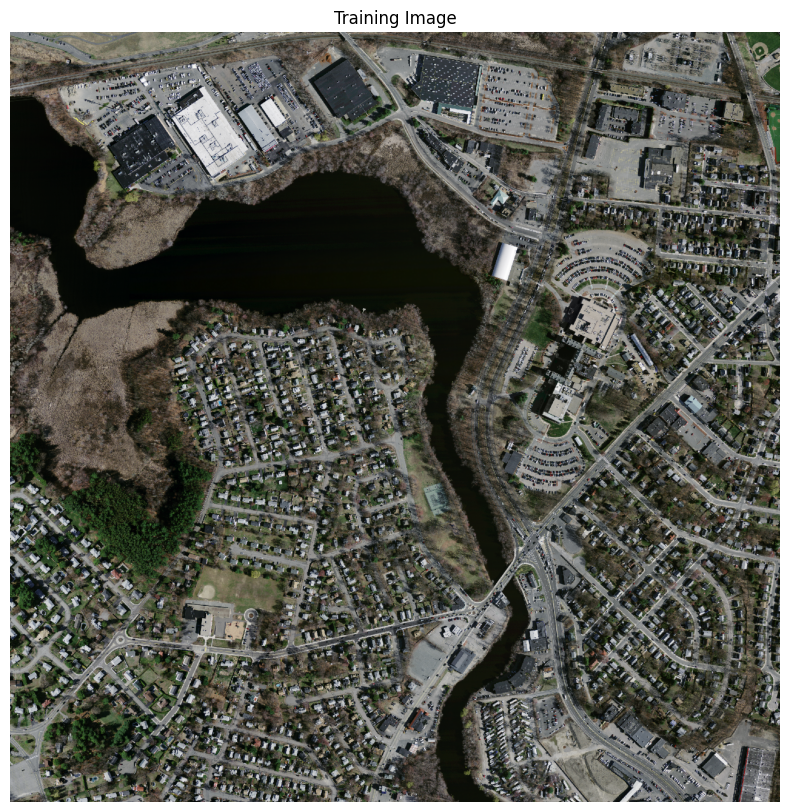

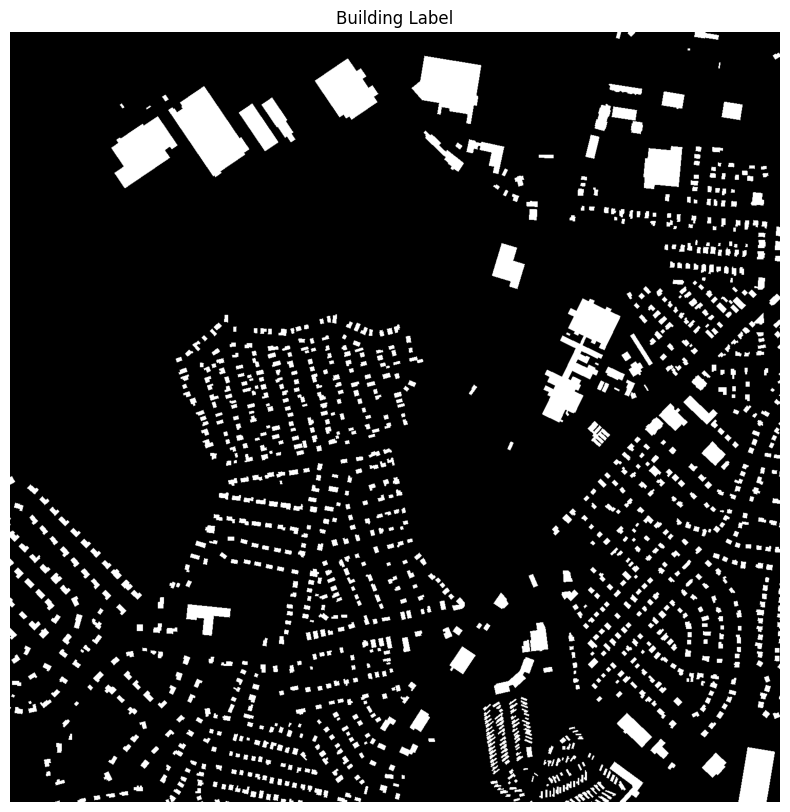

In [5]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

image_path = os.path.join(
    BASE,
    "train",
    "22678915_15.tiff"
)

label_path = os.path.join(
    BASE,
    "train_labels",
    "22678915_15.tif"
)

with rasterio.open(image_path) as src:
    image = src.read()

with rasterio.open(label_path) as src:
    label = src.read(1)

print("Image shape:", image.shape)
print("Label shape:", label.shape)

# Display image
plt.figure(figsize=(10, 10))

if image.shape[0] >= 3:
    rgb = np.transpose(image[:3], (1, 2, 0))

    # Normalize for display
    rgb = rgb.astype(float)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    plt.imshow(rgb)
else:
    plt.imshow(image[0], cmap="gray")

plt.title("Training Image")
plt.axis("off")
plt.show()


# Display label
plt.figure(figsize=(10, 10))
plt.imshow(label, cmap="gray")
plt.title("Building Label")
plt.axis("off")
plt.show()

**image_path** → specifies the location of the training satellite image.
**label_path** → specifies the location of the corresponding building label.  
**rasterio.open**() → opens the TIFF files.  
**src.read**() → loads all image bands.  
**src.read**(1) → loads the first band of the label image.  
**np.transpose**() → changes the image dimensions into the format required for displaying an RGB image.  
**Normalization** → scales pixel values between 0 and 1 to improve visualization.  
**plt.imshow**() → displays the image and label.  
**cmap="gray"** → displays the building label in grayscale.


**“Training Image”** showing the satellite imagery and **“Building Label”** showing the corresponding ground-truth building information.

# **Analyzing the Building Label Values**

In this section, the ground-truth building label is loaded from the training
dataset and its pixel values are analyzed.

The code identifies the shape and data type of the label image, as well as
its minimum and maximum pixel values. It also determines the unique pixel
values present in the label and counts how many pixels belong to each value.

This analysis helps us understand how buildings and background areas are
represented in the label image before further processing.

In [34]:
import os
import numpy as np
import rasterio

# Define the label file path
label_path = os.path.join(
    BASE,
    "train_labels",
    "22678915_15.tif"
)

# Load the building label
with rasterio.open(label_path) as src:
    label = src.read(1)

# Analyze the label values
unique_values, counts = np.unique(label, return_counts=True)

print("Label shape:", label.shape)
print("Data type:", label.dtype)
print("Minimum value:", label.min())
print("Maximum value:", label.max())

print("\nNumber of unique values:", len(unique_values))
print("Unique values:", unique_values)

print("\nPixel counts:")
for value, count in zip(unique_values, counts):
    print(f"Value {value}: {count:,} pixels")

Label shape: (1500, 1500)
Data type: uint8
Minimum value: 0
Maximum value: 255

Number of unique values: 2
Unique values: [  0 255]

Pixel counts:
Value 0: 2,012,517 pixels
Value 255: 237,483 pixels


Loads the **label file** from the training-label folder.  
Checks the **label dimensions** using label.shape.  
Checks the **data type** using label.dtype.  
Finds the **minimum and maximum** pixel values.  
Uses **np.unique()** to identify the different label values.  
Counts the number of pixels for each label value.


For this dataset, the result shows:

0 → background
255 → building
Image size → 1500 × 1500
Data type → uint8

So this  confirms that our building labels are represented as a binary mask using values 0 and 255.

# **Converting the Building Label into a Binary Mask**

In this section, the original building label, which uses pixel values of
`0` and `255`, is converted into a binary mask containing only `0` and `1`.

Pixels with a value of `255` are identified as buildings and converted to
`1`, while all other pixels are treated as background and converted to `0`.

The code then checks the shape and unique values of the new binary mask and
calculates the total number of background and building pixels.

This binary representation provides a simpler format for further image
processing and model training.

In [35]:
# Convert the label from 0/255 to a binary mask of 0/1

building_mask = (label == 255).astype(np.uint8)

print("Building mask shape:", building_mask.shape)
print("Unique values:", np.unique(building_mask))

print("\nBackground pixels:", np.sum(building_mask == 0))
print("Building pixels:", np.sum(building_mask == 1))

Building mask shape: (1500, 1500)
Unique values: [0 1]

Background pixels: 2012517
Building pixels: 237483


**original label:**

0   → Background
255 → Building

is **converted to:**

0 → Background
1 → Building

The line

**building_mask = (label == 255).astype(np.uint8)**

# **Visualizing the Original Image and Building Label**

In this section, the training satellite image and its corresponding
building label are loaded and displayed for visual inspection.

The image bands are rearranged from `(Bands, Height, Width)` to
`(Height, Width, Bands)` so that the first three bands can be displayed
as an RGB image.

Each RGB band is normalized independently to improve the appearance of
the satellite image.

The original satellite image and the corresponding building label are
then displayed separately. This visualization helps verify the
relationship between the input image and its ground-truth building
annotations before proceeding with further processing.

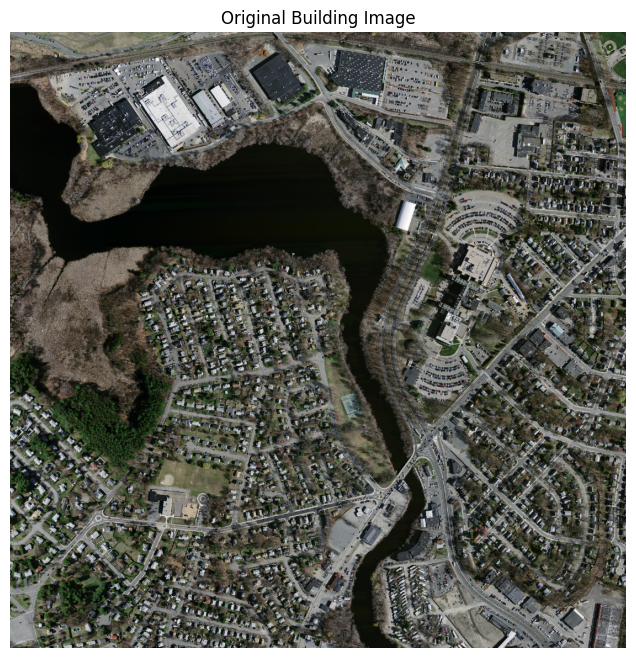

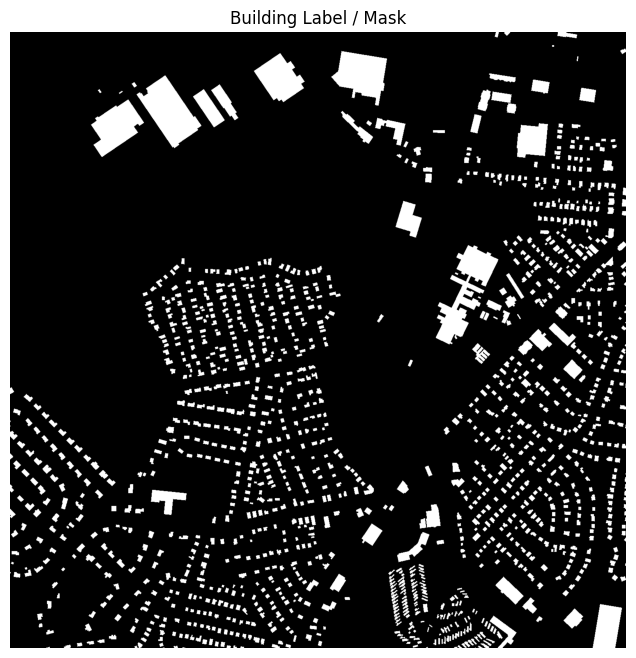

In [7]:
import matplotlib.pyplot as plt
import rasterio
import os
import numpy as np

image_path = os.path.join(
    BASE,
    "train",
    "22678915_15.tiff"
)

label_path = os.path.join(
    BASE,
    "train_labels",
    "22678915_15.tif"
)

with rasterio.open(image_path) as src:
    image = src.read()

with rasterio.open(label_path) as src:
    label = src.read(1)

# Convert RGB from (3, H, W) to (H, W, 3)
rgb = np.transpose(image, (1, 2, 0))

# Normalize RGB for display
rgb = rgb.astype(np.float32)

for band in range(3):
    bmin = rgb[:, :, band].min()
    bmax = rgb[:, :, band].max()
    rgb[:, :, band] = (
        (rgb[:, :, band] - bmin) /
        (bmax - bmin + 1e-8)
    )

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("Original Building Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(label, cmap="gray")
plt.title("Building Label / Mask")
plt.axis("off")
plt.show()

# **Verifying the Training Label Data**

In this section, the training label file is loaded and its basic properties
are examined.

The code checks the label image dimensions, data type, minimum and maximum
pixel values, and the number of pixels corresponding to each unique label
value.

This verification confirms how the ground-truth building information is
encoded in the training dataset and ensures that the label data is
correctly loaded before further processing.

In [8]:
import rasterio
import numpy as np
import os

BASE = "/content/drive/MyDrive/Building_Counting_Project1/tiff"

label_path = os.path.join(
    BASE,
    "train_labels",
    "22678915_15.tif"
)

with rasterio.open(label_path) as src:
    label = src.read(1)

unique, counts = np.unique(label, return_counts=True)

print("Shape:", label.shape)
print("Data type:", label.dtype)
print("Minimum:", label.min())
print("Maximum:", label.max())

print("\nUnique values:")
for value, count in zip(unique, counts):
    print(f"{value}: {count:,} pixels")

Shape: (1500, 1500)
Data type: uint8
Minimum: 0
Maximum: 255

Unique values:
0: 2,012,517 pixels
255: 237,483 pixels


# **Install the required packages**

In [9]:
!pip install -q rasterio segmentation-models-pytorch albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00


# **Checking the Deep Learning Environment and GPU**

In this section, the required libraries for deep learning and image
processing are imported.

PyTorch is used for building and running the deep learning model, while
Rasterio and OpenCV are used for handling and processing satellite imagery.
NumPy and Matplotlib are used for numerical operations and visualization.

The code also checks the installed PyTorch version and determines whether
Google Colab has access to a GPU.

If a GPU is available, its name is displayed. GPU acceleration can
significantly improve the speed of model training and inference compared
with using only the CPU.

In [10]:
import torch
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU: True
GPU: Tesla T4


# **Defining Training, Validation, and Test Dataset Paths**

In this section, the folder paths for the training, validation, and test
datasets are defined.

The dataset is organized into separate folders for satellite images and
their corresponding building labels. Defining these paths as variables
makes it easier to access the different parts of the dataset throughout
the project.

The dataset is divided into three groups:

- **Training data:** Used to train the deep learning model.
- **Validation data:** Used to evaluate the model during development and
  monitor its performance on unseen images.
- **Test data:** Used for the final evaluation of the trained model.

The code prints the training image and label paths to verify that the
directories have been defined correctly.

In [11]:
BASE = "/content/drive/MyDrive/Building_Counting_Project1/tiff"

TRAIN_IMAGES = f"{BASE}/train"
TRAIN_LABELS = f"{BASE}/train_labels"

VAL_IMAGES = f"{BASE}/val"
VAL_LABELS = f"{BASE}/val_labels"

TEST_IMAGES = f"{BASE}/test"
TEST_LABELS = f"{BASE}/test_labels"

print(TRAIN_IMAGES)
print(TRAIN_LABELS)

/content/drive/MyDrive/Building_Counting_Project1/tiff/train
/content/drive/MyDrive/Building_Counting_Project1/tiff/train_labels


# **Creating a Custom Building Dataset**

In this section, a custom PyTorch `Dataset` class named `BuildingDataset`
is created to prepare the satellite images and their corresponding
building masks for deep learning.

The dataset reads the satellite images and matching label files from the
specified directories. Large images are divided into smaller random
512 × 512 pixel crops. Multiple random samples can be generated from each
image to provide more training samples to the model.

The image data is converted into the format required by PyTorch and
normalized to a range of approximately 0 to 1. The building labels are
converted into a binary mask where building pixels are represented by `1`
and background pixels by `0`.

Finally, both the image and its corresponding mask are converted into
PyTorch tensors so they can be directly used by a deep learning model.

In [12]:
import os
import random
import numpy as np
import rasterio
import torch

from torch.utils.data import Dataset


class BuildingDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        crop_size=512,
        samples_per_image=10
    ):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.crop_size = crop_size
        self.samples_per_image = samples_per_image

        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".tif", ".tiff"))
        ])

    def __len__(self):
        return len(self.images) * self.samples_per_image

    def __getitem__(self, idx):

        image_name = self.images[idx % len(self.images)]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        # Label uses .tif while image may use .tiff
        label_name = os.path.splitext(image_name)[0] + ".tif"

        label_path = os.path.join(
            self.mask_dir,
            label_name
        )

        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)

        with rasterio.open(label_path) as src:
            mask = src.read(1)

        # Convert CHW -> HWC
        image = np.transpose(image, (1, 2, 0))

        h, w = mask.shape

        # Random crop
        if h > self.crop_size:
            y = random.randint(
                0,
                h - self.crop_size
            )
        else:
            y = 0

        if w > self.crop_size:
            x = random.randint(
                0,
                w - self.crop_size
            )
        else:
            x = 0

        image = image[
            y:y+self.crop_size,
            x:x+self.crop_size
        ]

        mask = mask[
            y:y+self.crop_size,
            x:x+self.crop_size
        ]

        # Normalize image
        image = image / 255.0

        # RGB HWC -> CHW
        image = np.transpose(image, (2, 0, 1))

        # Binary mask
        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask[None, :, :],
            dtype=torch.float32
        )

        return image, mask

**Dataset** → PyTorch framework used to create a custom dataset.  
**crop_size=512** → extracts 512 × 512 pixel image patches.   
**samples_per_image=10** → generates 10 samples from each image.  
__len__() → determines the total number of available samples.  
__getitem__() → loads and prepares one image-mask pair.  
**random crop** → selects different portions of large images for training.  
**image / 255.0** → normalizes the image pixel values.  
**mask > 0** → converts the original label into a binary building mask.  
**torch.tensor**() → converts the processed data into PyTorch tensors.

**Important**: This is a significant section  because it connects  raw satellite imagery and building labels to the deep learning training process.

# **Creating the Training and Validation Datasets**

In this section, the `BuildingDataset` class created in the previous step
is used to create separate training and validation datasets.

The training dataset uses 512 × 512 pixel crops and generates 10 samples
per image. The validation dataset uses the same crop size but generates
5 samples per image.

The number of samples in each dataset is then printed to verify that the
datasets have been created correctly.

The training dataset will be used to teach the model to identify buildings,
while the validation dataset will be used to evaluate the model during
training on data that was not used for learning.

In [13]:
train_dataset = BuildingDataset(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    crop_size=512,
    samples_per_image=10
)

val_dataset = BuildingDataset(
    VAL_IMAGES,
    VAL_LABELS,
    crop_size=512,
    samples_per_image=5
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 1050
Validation samples: 20


# **Creating DataLoaders for Training and Validation**

In this section, PyTorch `DataLoader` objects are created for the training
and validation datasets.

A DataLoader loads the prepared image and building-mask samples in batches,
which allows the deep learning model to process multiple samples at the
same time instead of loading the entire dataset into memory.

The training data is shuffled so that the model receives the training
samples in a different order during each iteration. The validation data is
not shuffled because its order does not need to be randomized for
evaluation.

A batch size of 4 is used, meaning that four image-mask pairs are processed
together in each batch.

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

**batch_size=4** → processes 4 samples at a time.  
**shuffle=True** → randomly rearranges training samples.  
**shuffle=False** → keeps validation samples in a fixed order.  
**num_workers=2** → uses two worker processes to load data.  
**pin_memory=True** → can improve data transfer from CPU memory to GPU memory when CUDA is being used.

# **Verifying a Batch of Training Data**

In this section, one batch of data is retrieved from the training
DataLoader to verify that the images and building masks have been loaded
and formatted correctly.

The shapes of the image and mask tensors are printed to confirm their
dimensions before they are passed to the deep learning model.

This check helps ensure that the data-loading pipeline is working correctly
and that the images and corresponding building masks have compatible
dimensions.

In [15]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Images: torch.Size([4, 3, 512, 512])
Masks: torch.Size([4, 1, 512, 512])


where:

4 = batch size  
3 = image channels/bands  
1 = building-mask channel  
512 × 512 = crop size

# **Visualizing a Training Image and Its Building Mask**

In this section, the first image and its corresponding building mask from
the training batch are displayed side by side.

The input image is converted from PyTorch's channel-first format
`(Channels, Height, Width)` to the display format
`(Height, Width, Channels)`.

The corresponding building mask is displayed in grayscale, where the
building and background areas can be visually distinguished.

This visualization provides a final check that the input satellite image
and its corresponding building mask are correctly aligned before training
the deep learning model.

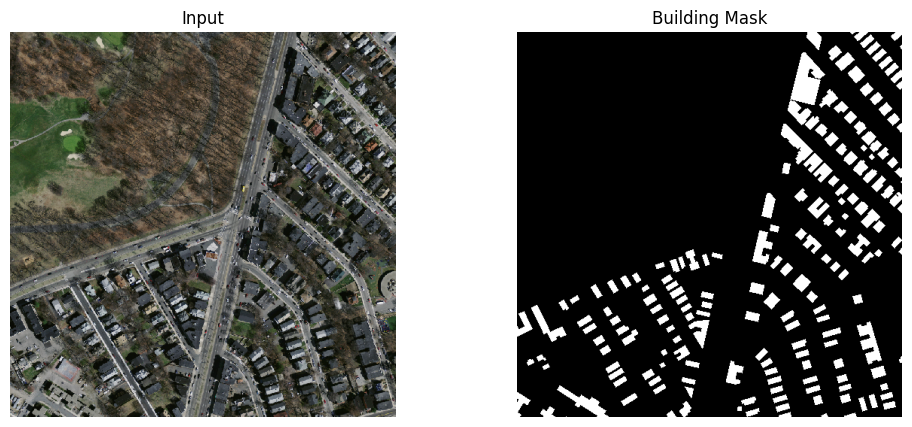

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[0][0], cmap="gray")
plt.title("Building Mask")
plt.axis("off")

plt.show()

# **Building the U-Net Segmentation Model**

In this section, a U-Net deep learning model is created for building
segmentation.

The model uses a ResNet34 encoder that is initialized with ImageNet
pre-trained weights. Using a pre-trained encoder provides the model with
features learned from a large image dataset, which can help when learning
features from satellite imagery.

The model is configured to accept 3-channel RGB images and produce a
single-channel output representing the building segmentation mask.

The model is then moved to the available computing device. If a GPU is
available, CUDA is used; otherwise, the model runs on the CPU.

The model is now ready for training on the prepared satellite images and
building masks.

In [17]:
import segmentation_models_pytorch as smp
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(device)

print("Model ready!")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model ready!


**Unet** → segmentation architecture used to identify building areas.   
**resnet34** → feature-extraction backbone (encoder).  
**imagenet** → uses pre-trained ImageNet weights.  
**in_channels=3** → accepts 3-channel RGB images.  
**classes=1** → produces one building-segmentation output channel.  
**activation=None** → leaves the final output as raw logits;   the appropriate activation can be applied by the loss function or during prediction.  
**device** → uses GPU if CUDA is available, otherwise CPU.

This is the point where our project moves from data preparation into the deep-learning model construction stage.

# **Defining the Loss Function**

In this section, the loss function used to train the building segmentation
model is defined.

Two complementary loss functions are combined:

- **Dice Loss** measures how well the predicted building regions overlap
  with the ground-truth building masks.
- **Binary Cross-Entropy (BCE) Loss** measures the difference between the
  predicted building probability and the actual binary label for each
  pixel.

Both losses are given equal weight, with 50% contribution from Dice Loss
and 50% from BCE Loss.

The combined loss provides a training objective that considers both pixel-
level classification and the overlap between predicted and actual building
regions.

In [18]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = torch.nn.BCEWithLogitsLoss()


def loss_function(pred, target):

    return (
        0.5 * dice_loss(pred, target)
        +
        0.5 * bce_loss(pred, target)
    )

**Total Loss = 0.5 × Dice Loss + 0.5 × BCE Loss**

**Dice Loss** → focuses on the overlap between predicted and actual buildings.  
**BCE Loss** → focuses on correctly classifying each pixel as building or background.  
**0.5 + 0.5** → gives both losses equal importance.

# **Configuring the Optimizer**

In this section, the AdamW optimizer is configured to update the parameters
of the U-Net model during training.

The optimizer determines how the model's weights are adjusted based on the
loss calculated during each training step.

A learning rate of `1e-4` is used to control the size of the parameter
updates. A weight decay of `1e-4` is also applied as a form of regularization
to help reduce overfitting.

The AdamW optimizer is commonly used for deep learning because it provides
adaptive parameter updates and separates weight decay from the gradient
update.

In [19]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

The optimizer controls how the model learns and updates itself after making predictions.

**AdamW** → optimization algorithm used to update model weights.  
**lr=1e-4** → learning rate; controls how quickly the model learns.  
**weight_decay=1e-4** → regularization that helps control overfitting.  
**model.parameters**() → tells the optimizer which model parameters it should update.

# **Training the U-Net Model**

This section trains the U-Net segmentation model using the training dataset for a fixed number of epochs.

The training process uses **20 epochs**. During each epoch, the model processes all training batches, calculates the segmentation loss, updates its weights through backpropagation, and records the average training loss.

The `tqdm` library is used to display a progress bar during training, including the current loss for each batch.

### Training Process

For each epoch:

1. The model is set to training mode using `model.train()`.
2. Training images and masks are loaded batch by batch.
3. The data is transferred to the selected device, such as the GPU.
4. Previous gradients are cleared using `optimizer.zero_grad()`.
5. The images are passed through the U-Net model to generate building predictions.
6. The combined Dice + BCE loss is calculated.
7. `loss.backward()` computes the gradients through backpropagation.
8. `optimizer.step()` updates the model weights.
9. The loss from each batch is accumulated.
10. The average training loss for the epoch is calculated and displayed.

### Important Parameters

- **EPOCHS = 20**: The model is trained over 20 complete passes through the training dataset.
- **train_loader**: Provides batches of training images and their corresponding building masks.
- **loss_function**: Measures the difference between the predicted building masks and the ground-truth masks.
- **optimizer**: Updates the model parameters based on the calculated gradients.
- **tqdm**: Displays the training progress and current batch loss.

The reported **Training Loss** should generally decrease as the model learns to segment buildings more accurately.



In [20]:
from tqdm.auto import tqdm

EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = loss_function(
            predictions,
            masks
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        progress.set_postfix(
            loss=loss.item()
        )

    train_loss /= len(train_loader)

    print(
        f"Epoch {epoch+1}: "
        f"Training Loss = {train_loss:.4f}"
    )

Epoch 1/20:   0%|          | 0/263 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 1: Training Loss = 0.4989


Epoch 2/20:   0%|          | 0/263 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

...

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 19: Training Loss = 0.1577


Epoch 20/20:   0%|          | 0/263 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 20: Training Loss = 0.1528



# **Saving the Trained U-Net Model**

### Purpose
The purpose of this section is to **save the trained U-Net model** so it can be reused later without retraining.

The model's learned weights are saved as a `.pth` file in Google Drive using `torch.save()`. This saved model can later be loaded for building segmentation and counting.


In [21]:
MODEL_PATH = "/content/drive/MyDrive/Building_Counting_Project1/unet_building_model.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Saved:", MODEL_PATH)

Saved: /content/drive/MyDrive/Building_Counting_Project1/unet_building_model.pth


# **Loading the Trained U-Net Model**

In this section, the previously trained U-Net model is recreated and its
saved weights are loaded from Google Drive.

The model is configured with the same ResNet34 architecture used during
training. The saved `.pth` file is loaded using `load_state_dict()`, and
`model.eval()` puts the model into evaluation mode for testing and prediction.

The model is also moved to the available device, either GPU (`cuda`) or CPU.


In [22]:
import torch
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)

MODEL_PATH = "/content/drive/MyDrive/Building_Counting_Project1/unet_building_model.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully!")
print("Device:", device)

Model loaded successfully!
Device: cuda


This section **loads the trained model so it can be used to make predictions** on new images.   
 **`smp.Unet()`** → recreates the U-Net model architecture.     
 **`encoder_name="resnet34"`** → uses ResNet34 as the encoder.         
 **`in_channels=3`** → accepts RGB images with 3 channels.     
 **`classes=1`** → produces one building segmentation output.        
 **`torch.load()`** → loads the saved model weights.                                    
 **`model.eval()`** → switches the model to evaluation mode for prediction.        
  **`device`** → uses the GPU if available; otherwise uses the CPU.

# **Preparing the Test Image for Model Prediction **

In this section, a test satellite image is loaded using Rasterio and prepared in the format required by the trained U-Net model.

The image is converted from CHW format to HWC format for normalization and then converted back to CHW format.

 The pixel values are normalized by dividing by 255.

  Finally, the image is converted into a PyTorch tensor and a batch dimension is added before sending it to the selected device.

In [23]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import torch

image_path = "/content/drive/MyDrive/Building_Counting_Project1/tiff/test/22828930_15.tiff"

with rasterio.open(image_path) as src:
    image = src.read().astype(np.float32)

print("Original shape:", image.shape)

# CHW -> HWC
rgb = np.transpose(image, (1, 2, 0))

# Normalize
rgb = rgb / 255.0

# HWC -> CHW
input_tensor = np.transpose(rgb, (2, 0, 1))

input_tensor = torch.tensor(
    input_tensor,
    dtype=torch.float32
).unsqueeze(0).to(device)

print("Model input:", input_tensor.shape)

Original shape: (3, 1500, 1500)
Model input: torch.Size([1, 3, 1500, 1500])


This section **prepares a test image so that it can be given to the trained U-Net model for prediction**.

**`rasterio`** → reads the TIFF satellite image.

 **CHW → HWC** → changes the image format for normalization.
 **`/255.0`** → normalizes pixel values to approximately 0–1.

 **HWC → CHW** → converts the image back to the format expected by PyTorch.

 **`unsqueeze(0)`** → adds a batch dimension.

 **`.to(device)`** → sends the image to the GPU or CPU used by the model.

 **`input_tensor.shape`** → verifies that the image has the correct input shape.

# **Generating the Predicted Building Mask**

In this section, the trained U-Net model is used to predict the building areas in the test image.

The model output is converted into probabilities using the sigmoid function. A threshold of 0.5 is then applied to create a binary building mask, where 1 represents building pixels and 0 represents background pixels.

In [24]:
with torch.no_grad():

    prediction = model(input_tensor)

    probability = torch.sigmoid(prediction)

    predicted_mask = (
        probability > 0.5
    ).float()

predicted_mask = predicted_mask[0, 0].cpu().numpy()

print("Predicted mask shape:", predicted_mask.shape)
print("Building pixels:", predicted_mask.sum())

Predicted mask shape: (1500, 1500)
Building pixels: 367561.0


This section uses the trained model to identify building pixels in the test image.  

**torch.no_grad**() → disables gradient calculation during prediction.  
**model(input_tensor)** → generates the model's prediction.  
**torch.sigmoid**() → converts the model output into probabilities.  
**>0.5** → classifies pixels as building or background.  
**predicted_mask** → contains the final binary building mask.  
**predicted_mask.sum**() → gives the total number of pixels predicted as buildings.

# **Visualizing the Model Prediction**

In this section, the original test image, building probability map, and predicted building mask are displayed side by side to visually evaluate the model's segmentation result.



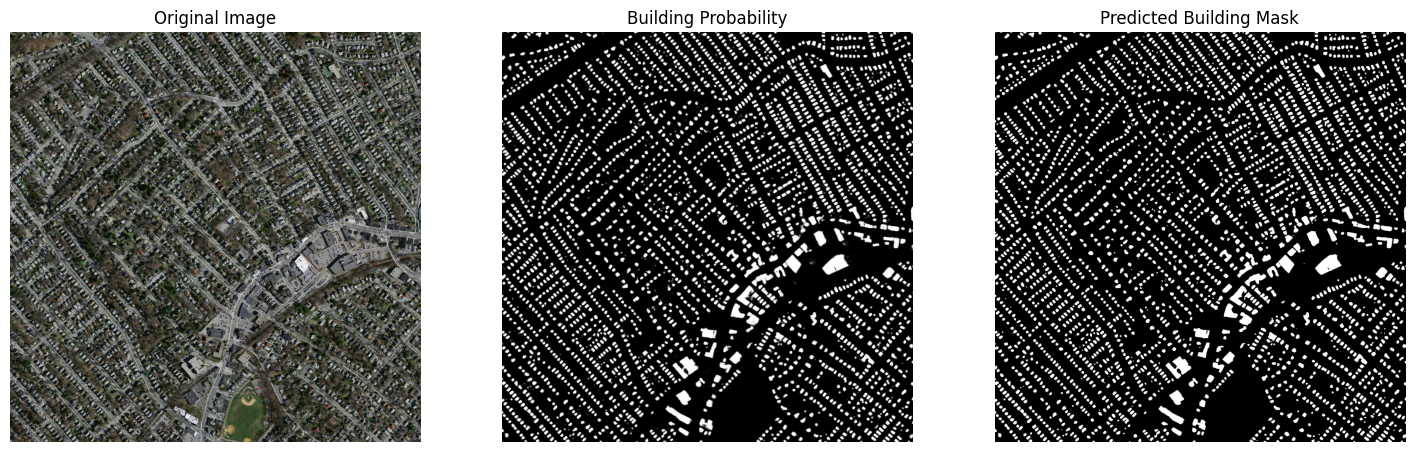

In [25]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(probability[0, 0].cpu().numpy(), cmap="gray")
plt.title("Building Probability")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Building Mask")
plt.axis("off")

plt.show()

This  helps us visually compare the original image with the model's prediction.

Original Image → shows the input satellite image.
Building Probability → shows how strongly the model predicts each pixel as a building.
Predicted Building Mask → shows the final binary building segmentation.
plt.subplot() → displays the three results side by side for easy comparison.

# **Visualizing Detected Buildings on the Original Image**

In this section, the predicted building mask is overlaid on the original satellite image to clearly highlight the areas identified as buildings by the model.

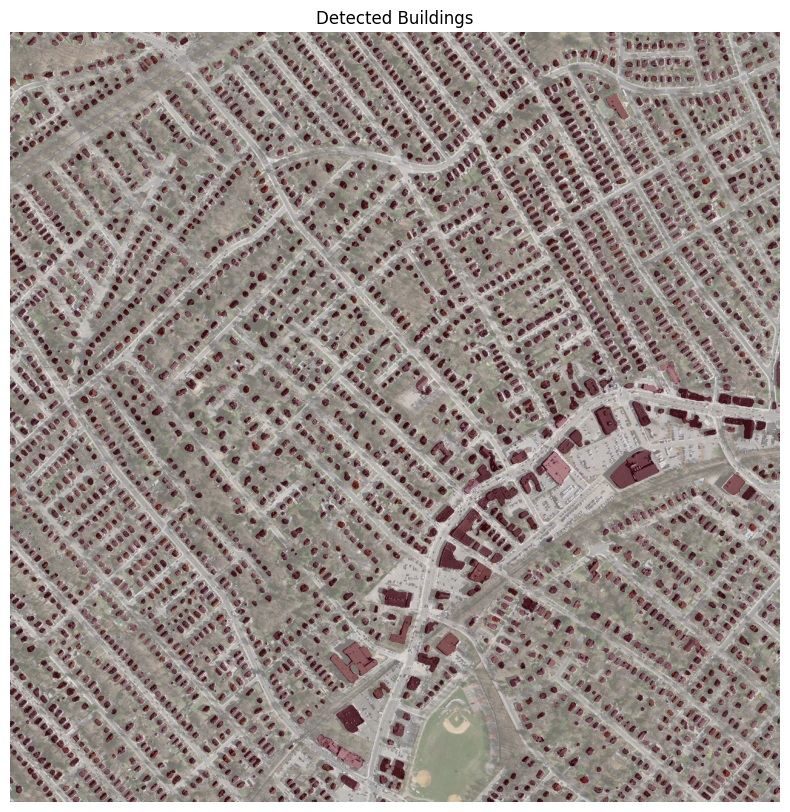

In [26]:
plt.figure(figsize=(10, 10))

plt.imshow(rgb)
plt.imshow(
    predicted_mask,
    cmap="Reds",
    alpha=0.45
)

plt.title("Detected Buildings")
plt.axis("off")

plt.show()

This section shows the detected buildings directly on the original satellite image.

**plt.imshow(rgb)** → displays the original satellite image.  
**predicted_mask** → represents the buildings detected by the model.   
**cmap="Reds"** → displays detected building areas in red.    
**alpha=0.45** → makes the mask partially transparent so the original image remains visible.     
**"Detected Buildings"** → gives the visualization a clear title.

# **Detecting Individual Buildings Using Connected Components**

In this section, the predicted binary building mask is analyzed using connected component analysis to identify separate connected building regions.

OpenCV's connectedComponentsWithStats() detects connected groups of building pixels and assigns each group a separate label.

In [27]:
import cv2
import numpy as np

binary_mask = (
    predicted_mask > 0.5
).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary_mask,
    connectivity=8
)

print("Total connected components:", num_labels - 1)

Total connected components: 2906


This identifies separate building regions in the predicted mask so they can be counted.

**binary_mask** → converts the predicted mask into a binary format.  
**cv2.connectedComponentsWithStats**() → detects separate connected regions.    
**connectivity=8** → considers pixels connected through edges or corners.   
**num_labels - 1** → gives the number of detected building components, excluding the background.  
**labels** → identifies which component each pixel belongs to.   
**stats** → provides information such as the size and bounding box of each component.   
**centroids** → provides the center position of each detected component.

# **Removing Small Regions and Counting Buildings**

In this , small detected regions are removed from the predicted mask to reduce noise and false detections.

A minimum building area of 20 pixels is used. Only connected components with an area equal to or greater than this threshold are considered valid buildings.

In [28]:
MIN_BUILDING_AREA = 20

clean_mask = np.zeros_like(binary_mask)

building_count = 0

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area >= MIN_BUILDING_AREA:

        clean_mask[labels == i] = 1
        building_count += 1

print("Predicted building count:", building_count)

Predicted building count: 2750


This  removes very small detections and counts the remaining building regions.

**MIN_BUILDING_AREA = 20** → sets the minimum size required for a detected building.  
**stats[i, cv2.CC_STAT_AREA]** → gets the area of each connected component.  
**clean_mask** → stores only the valid building regions.  
**area >= MIN_BUILDING_AREA** → keeps components large enough to be considered buildings.  
**building_count** → counts the number of valid detected buildings.  
**print**() → displays the final predicted building count.

# **Visualizing and Numbering Detected Buildings**

In this section, the detected buildings are visualized on the original satellite image using bounding boxes and labels.

Each valid building component is marked with a bounding box and a number. The total number of detected buildings is also displayed in the title.

In [29]:
plt.figure(figsize=(12, 12))

plt.imshow(rgb)

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area >= MIN_BUILDING_AREA:

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        cx, cy = centroids[i]

        plt.text(
            cx,
            cy,
            str(i),
            fontsize=5
        )

        plt.gca().add_patch(
            plt.Rectangle(
                (x, y),
                w,
                h,
                fill=False,
                linewidth=0.7
            )
        )

plt.title(
    f"Detected Buildings: {building_count}"
)

plt.axis("off")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

This shows each detected building with a box and number so the counting result can be visually checked.

**plt.imshow(rgb)** → displays the original satellite image.   
**Bounding box** → outlines each detected building region.  
**centroids** → provides the center position where the building number is displayed.  
**plt.text**() → places a number on each detected building.    
**plt.Rectangle**() → draws a box around each building.  
**building_count** → displays the total number of detected buildings in the title.

# **Creating a Function for Full-Image Prediction**

In this section, a function called predict_full_image() is created to process a complete test image and generate a building probability map using the trained U-Net model.

The function loads the image, normalizes it, converts it into a PyTorch tensor, performs prediction, and returns the predicted building probabilities.

In [1]:
import os
import numpy as np
import rasterio
import torch
from tqdm.auto import tqdm

TEST_IMAGES = "/content/drive/MyDrive/Building_Counting_Project1/tiff/test"
TEST_LABELS = "/content/drive/MyDrive/Building_Counting_Project1/tiff/test_labels"

def predict_full_image(image_path):

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    # CHW -> HWC
    image = np.transpose(image, (1, 2, 0))

    # Normalize
    image = image / 255.0

    # HWC -> CHW
    image = np.transpose(image, (2, 0, 1))

    tensor = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probability = torch.sigmoid(output)

    probability = probability[0, 0].cpu().numpy()

    return probability

This  creates a reusable function that predicts building probabilities for a complete satellite image.

**TEST_IMAGES** → stores the path to the test images.  
**TEST_LABELS** → stores the path to the corresponding test labels.    
**predict_full_image**() → performs prediction on one complete image.   
**/255.0** → normalizes the image pixel values.   
**torch.no_grad**() → performs prediction without calculating gradients.    
**torch.sigmoid**() → converts model output into building probabilities.    
**return probability** → returns the probability map for further processing.

# **Calculating Segmentation Evaluation Metrics**

In this section, a function called calculate_metrics() is created to evaluate how accurately the model's predicted building mask matches the true building mask.

The function calculates four important segmentation metrics: Dice Score, IoU, Precision, and Recall.

In [2]:
def calculate_metrics(pred_mask, true_mask):

    pred = pred_mask.astype(bool)
    true = true_mask.astype(bool)

    TP = np.logical_and(pred, true).sum()
    FP = np.logical_and(pred, ~true).sum()
    FN = np.logical_and(~pred, true).sum()

    intersection = TP
    union = np.logical_or(pred, true).sum()

    dice = (2 * intersection) / (
        2 * intersection + FP + FN + 1e-8
    )

    iou = intersection / (
        union + 1e-8
    )

    precision = TP / (
        TP + FP + 1e-8
    )

    recall = TP / (
        TP + FN + 1e-8
    )

    return dice, iou, precision, recall

This  measures how accurately the model detects and segments buildings.

**TP (True Positive)**→ pixels correctly identified as buildings.  
**FP (False Positive)**→ background pixels incorrectly identified as buildings.  
**FN (False Negative)** → building pixels missed by the model.  
**Dice Score** → measures the overlap between predicted and true building areas.  
**IoU** → measures the intersection between prediction and ground truth compared with their union.  
**Precision** → measures how many predicted building pixels are actually buildings.  
**Recall** → measures how many actual building pixels were successfully detected.  
**1e-8** → a very small value added to avoid division-by-zero errors.

# **Remounting and Verifying Google Drive**

In this section, Google Drive is remounted and its contents are displayed to verify that the required project files and folders are accessible.

In [7]:
from google.colab import drive
import os

# Remount Drive
drive.mount("/content/drive", force_remount=True)

print("\nTop-level Drive contents:")
for item in os.listdir("/content/drive"):
    print(item)

print("\nMyDrive contents:")
for item in os.listdir("/content/drive/MyDrive"):
    print(item)

Mounted at /content/drive

Top-level Drive contents:
.shortcut-targets-by-id
MyDrive
.Trash-0
.Encrypted

MyDrive contents:
label_class_dict.csv
metadata.csv
Colab Notebooks
Building_Counting_Project
Building_Counting_Research_Paper_Summary.xlsx
Building_Counting_Project1


This section checks that Google Drive is properly connected and the project files are available.

**drive.mount(**) → connects Google Drive to Google Colab.  
**force_remount=True** → forces Colab to reconnect to Drive.   
**os.listdir**() → displays the files and folders in Drive.    
/content/drive/MyDrive → shows the user's main Google Drive files and project folders.

# **Locating the Project Folder**

In this section, the Google Drive directory is searched to find all locations where the Building_Counting_Project1 project folder exists.

In [8]:
import os

target = "Building_Counting_Project1"

found = []

for root, dirs, files in os.walk("/content/drive"):
    if target in dirs:
        path = os.path.join(root, target)
        found.append(path)

print("\nFound project folders:")

for path in found:
    print(path)


Found project folders:
/content/drive/MyDrive/Building_Counting_Project1
/content/drive/.Encrypted/MyDrive/Building_Counting_Project1


This section finds and verifies the location of the project folder in Google Drive.

**target** → specifies the project folder name to search for.   
**os.walk**() → searches through the Drive folders and subfolders.    
**found** → stores the paths where the project folder is found.   
**os.path.join**() → creates the complete path to the project folder.      
**print**() → displays all detected project folder locations.

# **Locating the Saved Model File**

In this , Google Drive is searched to locate the saved unet_building_model.pth file and verify that the trained model is available.

In [9]:
import os

for root, dirs, files in os.walk("/content/drive"):
    if "unet_building_model.pth" in files:
        print("MODEL FOUND:")
        print(os.path.join(root, "unet_building_model.pth"))

MODEL FOUND:
/content/drive/MyDrive/Building_Counting_Project1/unet_building_model.pth


**os.walk**() → searches through all folders in Google Drive.  
"**unet_building_model.pth**" in files → checks whether the saved model file is present.  
**os.path.join**() → creates the complete path to the model file.  
**MODEL FOUND** → confirms that the trained model has been successfully located.

# **Defining Project Paths and Verifying Files**

In this section, the paths for the project, training data, validation data, test data, test labels, and trained model are defined.

The os.path.exists() function is then used to verify that each required folder and the saved model file are available.

In [10]:
import os

PROJECT = "/content/drive/MyDrive/Building_Counting_Project1"
BASE = os.path.join(PROJECT, "tiff")

TRAIN_IMAGES = os.path.join(BASE, "train")
TRAIN_LABELS = os.path.join(BASE, "train_labels")

VAL_IMAGES = os.path.join(BASE, "val")
VAL_LABELS = os.path.join(BASE, "val_labels")

TEST_IMAGES = os.path.join(BASE, "test")
TEST_LABELS = os.path.join(BASE, "test_labels")

MODEL_PATH = os.path.join(
    PROJECT,
    "unet_building_model.pth"
)

print("PROJECT:", os.path.exists(PROJECT))
print("BASE:", os.path.exists(BASE))
print("TRAIN:", os.path.exists(TRAIN_IMAGES))
print("VAL:", os.path.exists(VAL_IMAGES))
print("TEST:", os.path.exists(TEST_IMAGES))
print("TEST LABELS:", os.path.exists(TEST_LABELS))
print("MODEL:", os.path.exists(MODEL_PATH))

PROJECT: True
BASE: True
TRAIN: True
VAL: True
TEST: True
TEST LABELS: True
MODEL: True


# **Checking Test Images and Labels**

In this section, the test image and label files are collected from their respective folders and checked to verify that the test dataset is available for evaluation.

Only .tif and .tiff files are included, and the file names are sorted for easier comparison.

In [11]:
test_files = sorted([
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".tif", ".tiff"))
])

label_files = sorted([
    f for f in os.listdir(TEST_LABELS)
    if f.lower().endswith((".tif", ".tiff"))
])

print("Test images:", len(test_files))
print("Test labels:", len(label_files))

print("\nFirst test images:")
print(test_files[:10])

print("\nFirst test labels:")
print(label_files[:10])

Test images: 10
Test labels: 10

First test images:
['22828930_15.tiff', '22828990_15.tiff', '22829050_15.tiff', '23429020_15.tiff', '23429080_15.tiff', '23578960_15.tiff', '23579005_15.tiff', '23729035_15.tiff', '23879080_15.tiff', '24179065_15.tiff']

First test labels:
['22828930_15.tif', '22828990_15.tif', '22829050_15.tif', '23429020_15.tif', '23429080_15.tif', '23578960_15.tif', '23579005_15.tif', '23729035_15.tif', '23879080_15.tif', '24179065_15.tif']


**test_files** → stores the test image file names.  
**label_files** → stores the corresponding test label file names.  
.**endswith((".tif", ".tiff"))** → selects only TIFF image files.
**sorted**() → arranges the file names in order.   
**len**() → counts the number of test images and labels.  
**[:10]** → displays the first 10 file names for verification.

In [13]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.9 MB/s eta 0:00:00


# **Verifying Deep Learning Libraries and GPU**

In this section, the versions of Segmentation Models PyTorch (SMP) and PyTorch are checked, along with the availability of CUDA for GPU acceleration.

In [15]:
import segmentation_models_pytorch as smp
import torch

print("SMP version:", smp.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

SMP version: 0.5.0
PyTorch version: 2.11.0+cu128
CUDA available: True


**smp.__version__** → displays the installed Segmentation Models PyTorch version.  
**torch.__version__** → displays the installed PyTorch version.  
**torch.cuda.is_available**() → checks whether a CUDA-enabled GPU is available.  
**True** → indicates that GPU acceleration is available.   
**False** → indicates that the model will use the CPU.

# **Loading the Trained Model for Evaluation**

In this section, the trained U-Net model is recreated and the saved model weights are loaded from Google Drive for evaluation on the test dataset.

The model is moved to the available device and placed in evaluation mode before making predictions.

In [16]:
import os
import torch
import segmentation_models_pytorch as smp

PROJECT = "/content/drive/MyDrive/Building_Counting_Project1"

MODEL_PATH = os.path.join(
    PROJECT,
    "unet_building_model.pth"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model loaded successfully!")
print("Model path:", MODEL_PATH)
print("Device:", device)

Model loaded successfully!
Model path: /content/drive/MyDrive/Building_Counting_Project1/unet_building_model.pth
Device: cuda


This section loads the trained U-Net model and prepares it for testing on the test images.

**MODEL_PATH** → specifies the location of the saved model.  
**smp.Unet**() → recreates the U-Net architecture.  
**torch.load**() → loads the trained model weights.     
**load_state_dict**() → applies the saved weights to the model.   
**model.to(device)** → moves the model to GPU or CPU.   
**model.eval**() → puts the model into evaluation mode.   
**Model loaded successfully!** → confirms that the trained model is ready for evaluation.

# **Preparing the Test Dataset**

In this section, the test image and test label folders are defined and verified before starting model evaluation.

The available test images are then collected and sorted to confirm the number of images that will be used for testing.

In [17]:
BASE = "/content/drive/MyDrive/Building_Counting_Project1/tiff"

TEST_IMAGES = os.path.join(BASE, "test")
TEST_LABELS = os.path.join(BASE, "test_labels")

print("Test images exist:", os.path.exists(TEST_IMAGES))
print("Test labels exist:", os.path.exists(TEST_LABELS))

test_files = sorted([
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".tif", ".tiff"))
])

print("Number of test images:", len(test_files))
print(test_files[:10])

Test images exist: True
Test labels exist: True
Number of test images: 10
['22828930_15.tiff', '22828990_15.tiff', '22829050_15.tiff', '23429020_15.tiff', '23429080_15.tiff', '23578960_15.tiff', '23579005_15.tiff', '23729035_15.tiff', '23879080_15.tiff', '24179065_15.tiff']


# **Creating the Full-Image Prediction Function**

In this section, a reusable function is created to generate a building probability map for a complete test image using the trained U-Net model.

The image is loaded, normalized in the same way as during training, converted into a tensor, and passed through the model to obtain building probabilities.

In [18]:
import os
import numpy as np
import torch
import rasterio

def predict_full_image(image_path):

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    # (3, H, W) -> (H, W, 3)
    image = np.transpose(image, (1, 2, 0))

    # Same normalization used during training
    image = image / 255.0

    # (H, W, 3) -> (3, H, W)
    image = np.transpose(image, (2, 0, 1))

    tensor = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probability = torch.sigmoid(output)

    return probability[0, 0].cpu().numpy()

# **Defining Segmentation Evaluation Metrics**

In this section, a function is created to calculate important metrics for evaluating the model's building segmentation performance.

The function compares the predicted building mask with the ground-truth mask and calculates Dice Score, IoU, Precision, and Recall.

In [19]:
def calculate_metrics(pred_mask, true_mask):

    pred = pred_mask.astype(bool)
    true = true_mask.astype(bool)

    TP = np.logical_and(pred, true).sum()
    FP = np.logical_and(pred, ~true).sum()
    FN = np.logical_and(~pred, true).sum()

    dice = (2 * TP) / (
        2 * TP + FP + FN + 1e-8
    )

    iou = TP / (
        TP + FP + FN + 1e-8
    )

    precision = TP / (
        TP + FP + 1e-8
    )

    recall = TP / (
        TP + FN + 1e-8
    )

    return dice, iou, precision, recall

**TP (True Positive)** → building pixels correctly detected.  
**FP (False Positive)** → non-building pixels incorrectly detected as buildings.  
**FN (False Negative)** → actual building pixels missed by the model.  
**Dice Score** → measures the overlap between predicted and actual building areas.   
**IoU** → measures the intersection between prediction and ground truth relative to their combined area.   
**Precision** → measures how many predicted building pixels are actually buildings.   
**Recall** → measures how many actual building pixels were correctly detected.   
**1e-8** → prevents division-by-zero errors.

# **Evaluating the Model on the Test Dataset**

In this section, the trained U-Net model is evaluated on all available test images.

For each test image, the model generates a building probability map, which is converted into a binary building mask using a threshold of 0.5. The corresponding ground-truth label is then loaded and compared with the prediction using Dice Score, IoU, Precision, and Recall.

The results for all test images are stored in a Pandas DataFrame for easy analysis

In [20]:
from tqdm.auto import tqdm
import pandas as pd

results = []

for filename in tqdm(test_files):

    image_path = os.path.join(
        TEST_IMAGES,
        filename
    )

    # Your images are .tiff but labels are .tif
    label_filename = (
        os.path.splitext(filename)[0] + ".tif"
    )

    label_path = os.path.join(
        TEST_LABELS,
        label_filename
    )

    if not os.path.exists(label_path):
        print("Missing label:", label_path)
        continue

    # Model prediction
    probability = predict_full_image(
        image_path
    )

    predicted_mask = probability >= 0.5

    # Ground truth
    with rasterio.open(label_path) as src:
        true_mask = src.read(1) > 0

    # Metrics
    dice, iou, precision, recall = calculate_metrics(
        predicted_mask,
        true_mask
    )

    results.append({
        "image": filename,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall
    })

results_df = pd.DataFrame(results)

print("\nEvaluation complete.")
print("Images evaluated:", len(results_df))

display(results_df)

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



Evaluation complete.
Images evaluated: 10


,image,dice,iou,precision,recall
0,22828930_15.tiff,0.782902,0.643253,0.805844,0.761230
1,22828990_15.tiff,0.800918,0.667943,0.797956,0.803903
2,22829050_15.tiff,0.845512,0.732369,0.860382,0.831147
3,23429020_15.tiff,0.845134,0.731803,0.876434,0.815993
4,23429080_15.tiff,0.820623,0.695811,0.814359,0.826984
5,23578960_15.tiff,0.804970,0.673598,0.807923,0.802038
6,23579005_15.tiff,0.834490,0.715986,0.884630,0.789728
7,23729035_15.tiff,0.815676,0.688728,0.829638,0.802177
8,23879080_15.tiff,0.812273,0.683888,0.808418,0.816165
9,24179065_15.tiff,0.793965,0.658326,0.839798,0.752875


**tqdm(test_files)** → shows the evaluation progress.  
**predict_full_image()** → generates the model prediction for each test image.  
**probability >= 0.5** → converts probabilities into a binary building mask.  
**true_mask** → loads the actual building mask from the test label.   
**calculate_metrics()** → calculates Dice, IoU, Precision, and Recall.   
**results** → stores the evaluation results for each image.  
**results_df** → creates a table containing the performance metrics for all test images.   
**display(results_df)** → displays the final evaluation results.

# **Calculating Overall Segmentation Performance**

In this section, the average performance of the model across all test images is calculated using the segmentation metrics obtained during evaluation.

The mean Dice Score, IoU, Precision, and Recall provide an overall summary of the model's building segmentation performance.

In [21]:
print("==========================================")
print("       BUILDING SEGMENTATION RESULTS")
print("==========================================")

print(f"Mean Dice      : {results_df['dice'].mean():.4f}")
print(f"Mean IoU       : {results_df['iou'].mean():.4f}")
print(f"Mean Precision : {results_df['precision'].mean():.4f}")
print(f"Mean Recall    : {results_df['recall'].mean():.4f}")

       BUILDING SEGMENTATION RESULTS
Mean Dice      : 0.8156
Mean IoU       : 0.6892
Mean Precision : 0.8325
Mean Recall    : 0.8002


**Mean Dice** → average overlap between predicted and actual building areas.  
**Mean IoU** → average intersection-over-union of the predicted and actual masks.  
**Mean Precision** → average accuracy of the predicted building pixels.   
**Mean Recall** → average percentage of actual building pixels detected.   
**.mean()** → calculates the average value across all evaluated test images.   
**.4f** → displays the results to 4 decimal places.

# **Creating a Building Counting Function**

In this section, a function is created to count individual buildings from a predicted building mask.

The function uses connected component analysis to identify separate building regions and ignores very small regions using a minimum area threshold.

In [22]:
import cv2

def count_buildings_from_mask(mask, min_area=20):

    binary = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )

    count = 0

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:
            count += 1

    return count

# **Evaluating Building Counting Performance**

In this section, the trained model is used to estimate the number of buildings in each test image.

For every test image, the predicted building mask is generated and compared with the ground-truth mask. Connected component analysis is then used to calculate both the actual and predicted building counts. The absolute error between the two counts is also calculated.

In [23]:
count_results = []

for filename in tqdm(test_files):

    image_path = os.path.join(
        TEST_IMAGES,
        filename
    )

    label_filename = (
        os.path.splitext(filename)[0] + ".tif"
    )

    label_path = os.path.join(
        TEST_LABELS,
        label_filename
    )

    probability = predict_full_image(
        image_path
    )

    predicted_mask = probability >= 0.5

    with rasterio.open(label_path) as src:
        true_mask = src.read(1)

    actual_count = count_buildings_from_mask(
        true_mask,
        min_area=20
    )

    predicted_count = count_buildings_from_mask(
        predicted_mask,
        min_area=20
    )

    count_results.append({
        "image": filename,
        "actual_count": actual_count,
        "predicted_count": predicted_count,
        "absolute_error": abs(
            actual_count - predicted_count
        )
    })

count_df = pd.DataFrame(count_results)

display(count_df)

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


,image,actual_count,predicted_count,absolute_error
0,22828930_15.tiff,2978,2750,228
1,22828990_15.tiff,1209,1177,32
2,22829050_15.tiff,1125,1090,35
3,23429020_15.tiff,1175,971,204
4,23429080_15.tiff,2893,2598,295
5,23578960_15.tiff,2631,2434,197
6,23579005_15.tiff,368,420,52
7,23729035_15.tiff,313,278,35
8,23879080_15.tiff,1343,1292,51
9,24179065_15.tiff,1097,982,115


# **Calculating Building Counting Performance**

In this section, the overall accuracy of the building counting system is measured using Mean Absolute Error (MAE) and Root Mean Square Error (RMSE).

These metrics compare the actual number of buildings with the number predicted by the model across all test images.

In [24]:
actual = count_df["actual_count"].values
predicted = count_df["predicted_count"].values

mae = np.mean(np.abs(actual - predicted))

rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)

print("==========================================")
print("          BUILDING COUNT RESULTS")
print("==========================================")

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

          BUILDING COUNT RESULTS
MAE  : 124.40
RMSE : 155.38


**MAE** → measures the average absolute difference between actual and predicted counts.   
**RMSE** → measures the average prediction error while giving more weight to larger errors.   
**Lower MAE and RMSE** → indicate smaller counting errors.

# **Preparing Validation Data for Counting Parameter Tuning**

In this section, the validation dataset is prepared to find suitable parameters for improving the building counting results.

The model predictions for all validation images are generated once and stored along with their true building counts. These stored predictions can then be used to test different counting parameters without repeatedly running the model.

In [27]:
# ============================================================
# VERSION 3 — COUNTING PARAMETER TUNING
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/Building_Counting_Project1/tiff"

VAL_IMAGES = os.path.join(BASE, "val")
VAL_LABELS = os.path.join(BASE, "val_labels")

TEST_IMAGES = os.path.join(BASE, "test")
TEST_LABELS = os.path.join(BASE, "test_labels")


# ------------------------------------------------------------
# Connected-component counter
# ------------------------------------------------------------

def count_buildings_from_mask(mask, min_area=20):

    binary = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )

    count = 0

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:
            count += 1

    return count


# ------------------------------------------------------------
# Calculate true count
# ------------------------------------------------------------

def get_true_count(label_path, min_area=20):

    with rasterio.open(label_path) as src:
        mask = src.read(1)

    return count_buildings_from_mask(
        mask,
        min_area=min_area
    )


# ------------------------------------------------------------
# Generate predictions for validation set once
# ------------------------------------------------------------

val_files = sorted([
    f for f in os.listdir(VAL_IMAGES)
    if f.lower().endswith(".tiff")
])

print("Validation images:", len(val_files))


val_predictions = []

for filename in tqdm(val_files):

    image_path = os.path.join(
        VAL_IMAGES,
        filename
    )

    label_filename = (
        os.path.splitext(filename)[0] + ".tif"
    )

    label_path = os.path.join(
        VAL_LABELS,
        label_filename
    )

    probability = predict_full_image(image_path)

    true_count = get_true_count(
        label_path,
        min_area=20
    )

    val_predictions.append({
        "image": filename,
        "probability": probability,
        "true_count": true_count
    })


print("Validation predictions generated.")

Validation images: 4


  0%|          | 0/4 [00:00<?, ?it/s]

Validation predictions generated.


# **Tuning the Counting Parameters**

In this section, different probability thresholds and minimum building areas are tested to find suitable parameters for building counting.

Each combination is evaluated on the validation dataset using MAE and RMSE. The results are then sorted by MAE so that the configurations with smaller counting errors can be identified.

In [28]:
# ============================================================
# TEST DIFFERENT THRESHOLDS AND MINIMUM AREAS
# ============================================================

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

min_areas = [
    5,
    10,
    20,
    30,
    50,
    75,
    100
]


tuning_results = []


for threshold in thresholds:

    for min_area in min_areas:

        actual_counts = []
        predicted_counts = []

        for item in val_predictions:

            probability = item["probability"]

            predicted_mask = (
                probability >= threshold
            )

            predicted_count = count_buildings_from_mask(
                predicted_mask,
                min_area=min_area
            )

            actual_counts.append(
                item["true_count"]
            )

            predicted_counts.append(
                predicted_count
            )


        actual_counts = np.array(
            actual_counts
        )

        predicted_counts = np.array(
            predicted_counts
        )


        mae = np.mean(
            np.abs(
                actual_counts -
                predicted_counts
            )
        )

        rmse = np.sqrt(
            np.mean(
                (
                    actual_counts -
                    predicted_counts
                ) ** 2
            )
        )


        tuning_results.append({
            "threshold": threshold,
            "min_area": min_area,
            "MAE": mae,
            "RMSE": rmse
        })


tuning_df = pd.DataFrame(
    tuning_results
)

# Sort by validation MAE
tuning_df = tuning_df.sort_values(
    "MAE"
).reset_index(drop=True)


print("=" * 70)
print("TOP VALIDATION COUNTING CONFIGURATIONS")
print("=" * 70)

display(
    tuning_df.head(15)
)

TOP VALIDATION COUNTING CONFIGURATIONS


,threshold,min_area,MAE,RMSE
0,0.60,5,43.75,50.672971
1,0.70,5,44.50,52.430907
2,0.55,5,45.25,52.356948
3,0.65,5,45.25,52.352173
4,0.50,5,46.00,52.014421
5,0.45,5,47.00,53.315101
6,0.60,10,48.25,57.216693
7,0.40,5,49.00,55.190579
8,0.45,10,49.25,56.844085
9,0.40,10,49.25,57.098599


# **Final Test Using the Selected Counting Parameters**

In this section, the counting parameters selected from the validation tuning process are applied to the test dataset.

A probability threshold of 0.60 and a minimum building area of 5 pixels are used to generate the final building counts. The predicted counts are compared with the actual counts, and the final MAE and RMSE are calculated.

In [29]:
# ============================================================
# FINAL TEST — VALIDATION-SELECTED COUNTING CONFIGURATION
# ============================================================

FINAL_THRESHOLD = 0.60
FINAL_MIN_AREA = 5

final_results = []

for filename in tqdm(test_files):

    image_path = os.path.join(
        TEST_IMAGES,
        filename
    )

    label_filename = (
        os.path.splitext(filename)[0] + ".tif"
    )

    label_path = os.path.join(
        TEST_LABELS,
        label_filename
    )

    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    probability = predict_full_image(
        image_path
    )

    predicted_mask = (
        probability >= FINAL_THRESHOLD
    )

    # --------------------------------------------------------
    # Predicted building count
    # --------------------------------------------------------

    predicted_count = count_buildings_from_mask(
        predicted_mask,
        min_area=FINAL_MIN_AREA
    )

    # --------------------------------------------------------
    # Ground-truth building count
    # IMPORTANT:
    # Keep the original reference-count definition.
    # --------------------------------------------------------

    with rasterio.open(label_path) as src:
        true_mask = src.read(1)

    actual_count = count_buildings_from_mask(
        true_mask,
        min_area=FINAL_MIN_AREA
    )

    error = predicted_count - actual_count

    final_results.append({
        "image": filename,
        "actual_count": actual_count,
        "predicted_count": predicted_count,
        "error": error,
        "absolute_error": abs(error)
    })


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

final_df = pd.DataFrame(
    final_results
)

display(final_df)


# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

actual = final_df["actual_count"].values
predicted = final_df["predicted_count"].values

final_mae = np.mean(
    np.abs(actual - predicted)
)

final_rmse = np.sqrt(
    np.mean(
        (actual - predicted) ** 2
    )
)

print()
print("=" * 70)
print("FINAL TEST BUILDING COUNT RESULTS")
print("=" * 70)

print(f"Threshold   : {FINAL_THRESHOLD}")
print(f"Min area    : {FINAL_MIN_AREA}")
print(f"MAE         : {final_mae:.2f}")
print(f"RMSE        : {final_rmse:.2f}")

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


,image,actual_count,predicted_count,error,absolute_error
0,22828930_15.tiff,3000,2848,-152,152
1,22828990_15.tiff,1213,1220,7,7
2,22829050_15.tiff,1129,1121,-8,8
3,23429020_15.tiff,1177,1050,-127,127
4,23429080_15.tiff,2918,2691,-227,227
5,23578960_15.tiff,2646,2519,-127,127
6,23579005_15.tiff,368,480,112,112
7,23729035_15.tiff,320,298,-22,22
8,23879080_15.tiff,1384,1318,-66,66
9,24179065_15.tiff,1103,1034,-69,69



FINAL TEST BUILDING COUNT RESULTS
Threshold   : 0.6
Min area    : 5
MAE         : 91.70
RMSE        : 113.64


**FINAL_THRESHOLD = 0.60** → probability threshold used to identify building pixels.  
**FINAL_MIN_AREA = 5** → minimum area required for a detected building.  
**predicted_count** → number of buildings detected by the model.  
**actual_count** → number of buildings in the ground-truth label.  
**error** → difference between predicted and actual building counts.  
**absolute_error** → size of the counting error without considering its direction.  
**final_df** → stores the final counting results for all test images.  
**final_mae** → average absolute counting error across the test dataset.  
**final_rmse** → overall counting error with greater influence from larger errors.  
**Final MAE and RMSE** → summarize the building counting performance on the test dataset.

# **Final Visualization Figures**

This section creates the final visual results of the building-counting model for three representative test images. It displays the original aerial image, ground-truth building mask, U-Net prediction, and predicted building boundaries together with the actual and predicted building counts.

The figures are also saved as PNG images for use in the project report or presentation.

In [32]:
# ============================================================
# FINAL VISUALIZATION FIGURES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# ------------------------------------------------------------
# Final counting configuration
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.60
FINAL_MIN_AREA = 5


# ------------------------------------------------------------
# Function to load RGB image
# ------------------------------------------------------------

def load_rgb_image(image_path):

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    image = np.transpose(image, (1, 2, 0))

    # Normalize for visualization
    image = image / 255.0

    image = np.clip(image, 0, 1)

    return image


# ------------------------------------------------------------
# Function to get building boundaries
# ------------------------------------------------------------

def get_building_boundaries(mask, min_area=5):

    binary = mask.astype(np.uint8)

    num_labels, labels, stats, _ = \
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )

    clean = np.zeros_like(binary)

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:
            clean[labels == i] = 1

    # Find contours
    contours, _ = cv2.findContours(
        clean,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    return clean, contours


# ------------------------------------------------------------
# Visualization function
# ------------------------------------------------------------

def visualize_building_result(filename):

    image_path = os.path.join(
        TEST_IMAGES,
        filename
    )

    label_filename = (
        os.path.splitext(filename)[0] + ".tif"
    )

    label_path = os.path.join(
        TEST_LABELS,
        label_filename
    )

    # Load image
    image = load_rgb_image(
        image_path
    )

    # Load ground truth
    with rasterio.open(label_path) as src:
        true_mask = src.read(1) > 0

    # Model prediction
    probability = predict_full_image(
        image_path
    )

    predicted_mask = (
        probability >= FINAL_THRESHOLD
    )

    # Clean predicted mask
    clean_pred, contours = get_building_boundaries(
        predicted_mask,
        min_area=FINAL_MIN_AREA
    )

    # Counts
    actual_count = count_buildings_from_mask(
        true_mask,
        min_area=FINAL_MIN_AREA
    )

    predicted_count = count_buildings_from_mask(
        predicted_mask,
        min_area=FINAL_MIN_AREA
    )

    error = abs(
        actual_count - predicted_count
    )

    # --------------------------------------------------------
    # Create boundary overlay
    # --------------------------------------------------------

    overlay = (
        image * 255
    ).astype(np.uint8).copy()

    cv2.drawContours(
        overlay,
        contours,
        -1,
        (255, 0, 0),
        2
    )

    overlay = overlay / 255.0

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 12)
    )

    fig.suptitle(
        f"Building Detection — {filename}",
        fontsize=16
    )

    # Original
    axes[0, 0].imshow(image)
    axes[0, 0].set_title(
        "Original Aerial Image"
    )
    axes[0, 0].axis("off")

    # Ground truth
    axes[0, 1].imshow(
        true_mask,
        cmap="gray"
    )
    axes[0, 1].set_title(
        f"Ground Truth\nBuildings: {actual_count}"
    )
    axes[0, 1].axis("off")

    # Prediction
    axes[1, 0].imshow(
        clean_pred,
        cmap="gray"
    )
    axes[1, 0].set_title(
        f"U-Net Prediction\nBuildings: {predicted_count}"
    )
    axes[1, 0].axis("off")

    # Boundary overlay
    axes[1, 1].imshow(
        overlay
    )
    axes[1, 1].set_title(
        f"Predicted Building Boundaries\n"
        f"Actual: {actual_count} | "
        f"Predicted: {predicted_count} | "
        f"Error: {error}"
    )
    axes[1, 1].axis("off")

    plt.tight_layout()

    # Save
    output_name = (
        os.path.splitext(filename)[0]
        + "_building_result.png"
    )

    output_path = os.path.join(
        "/content",
        output_name
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {output_path}"
    )


# ============================================================
# Generate three representative figures
# ============================================================

representative_images = [
    "22828930_15.tiff",
    "23429080_15.tiff",
    "23579005_15.tiff"
]

for filename in representative_images:

    print()
    print("=" * 70)
    print(filename)
    print("=" * 70)

    visualize_building_result(filename)

Output hidden; open in https://colab.research.google.com to view.

**Original Aerial Image** → shows the input satellite/aerial image.  
**Ground Truth** → shows the actual building mask from the dataset.  
**U-Net Prediction** → shows the buildings detected by the trained model.  
**Predicted Building Boundaries** → displays the detected building outlines over the original image.

# **Overall Workflow of the Proposed Building Counting System**

```text
                 BUILDING COUNTING SYSTEM

                         Aerial TIFF
                              │
                              ▼
                    Data Preprocessing
                              │
                              ▼
                     512×512 Image Crops
                              │
                              ▼
                    ┌───────────────────┐
                    │   U-Net Model     │
                    │   + ResNet34      │
                    │    Encoder        │
                    └───────────────────┘
                              │
                              ▼
                     Model Training
                              │
                  Dice Loss + BCE Loss
                              │
                              ▼
                    Trained U-Net Model
                              │
                              ▼
                       Test Aerial Image
                              │
                              ▼
                    Building Probability
                           Map
                              │
                     Threshold = 0.60
                              │
                              ▼
                    Binary Building Mask
                              │
                              ▼
                  Connected Components
                              │
                     Min Area = 5
                         pixels
                              │
                              ▼
                      Building Count
                              │
                              ▼
                 ┌─────────────────────┐
                 │  Segmentation       │
                 │  Evaluation         │
                 │                     │
                 │ Dice | IoU          │
                 │ Precision | Recall  │
                 └─────────────────────┘
                              │
                              ▼
                  Counting Evaluation
                              │
                       MAE | RMSE
                              │
                              ▼
                   Final Visualization
                              │
            ┌────────────────────────────────┐
            │ Original Image                  │
            │ Ground Truth Mask               │
            │ U-Net Prediction                │
            │ Building Boundary Overlay       │
            └────────────────────────────────┘
                              │
                              ▼
                    FINAL BUILDING
                    COUNTING RESULTS
```


# **System Methodology**

The proposed system uses a deep learning-based image segmentation approach to detect and count buildings from aerial TIFF images. The methodology consists of several stages, beginning with dataset preparation and image preprocessing, followed by U-Net model training and building segmentation.

The trained U-Net model generates a pixel-wise probability map indicating the likelihood that each pixel belongs to a building. A probability threshold of **0.60** is then applied to obtain a binary building mask. Connected-component analysis is used to identify individual building regions, while a minimum area of **5 pixels** is applied to remove very small regions.

The detected building regions are counted to obtain the final building count. The system is evaluated using both segmentation metrics, including **Dice Score, IoU, Precision, and Recall**, and counting metrics, including **Mean Absolute Error (MAE)** and **Root Mean Square Error (RMSE)**.

The complete methodology can therefore be summarized as:

**Aerial Image → Preprocessing → U-Net Segmentation → Probability Map → Binary Mask → Connected Components → Building Detection → Building Count → Performance Evaluation**


# **Dataset Description**

The dataset used in this project consists of high-resolution aerial TIFF images and their corresponding building-label masks. The dataset is divided into **training, validation, and testing subsets** to develop and evaluate the building segmentation and counting system.

The aerial images have a spatial size of **1500 × 1500 pixels** and contain three image channels. The corresponding label images identify building regions using binary pixel values, where **0 represents the background** and **255 represents building areas**.

### Dataset Organization

| Dataset    | Images  | Labels | Purpose                                         |
| ---------- | ------- | ------ | ----------------------------------------------- |
| Training   | `.tiff` | `.tif` | Train the U-Net model                           |
| Validation | `.tiff` | `.tif` | Validate the model and tune counting parameters |
| Testing    | `.tiff` | `.tif` | Final performance evaluation                    |

During training, the 1500 × 1500 images are divided into **512 × 512 crops**. This allows the model to learn building features from smaller image regions while reducing the computational requirements during training.

The dataset structure used in the project is:

```text
Building_Counting_Project1/
│
└── tiff/
    ├── train/
    ├── train_labels/
    ├── val/
    ├── val_labels/
    ├── test/
    └── test_labels/
```

The image and label files use the same filename stem, while the image files use the `.tiff` extension and the corresponding labels use the `.tif` extension.


# **Image Preprocessing**

Image preprocessing is performed before training the U-Net model to convert the raw aerial images and building labels into a suitable format for deep learning. The TIFF images are loaded and converted into numerical arrays, while the corresponding label images are converted into binary building masks.

The original aerial images have a size of **1500 × 1500 pixels**. To make training more efficient, random **512 × 512 pixel crops** are extracted from the images.

The image pixel values are normalized by dividing them by **255**, converting the values to a range between **0 and 1**. The building labels are converted into binary masks, where building pixels are represented by **1** and background pixels by **0**.

### Preprocessing Steps

```text
Original Aerial Image
        │
        ▼
   Load TIFF Image
        │
        ▼
   Pixel Normalization
      / 255.0
        │
        ▼
   512 × 512 Cropping
        │
        ▼
   Model Input Image
```

The corresponding building label follows:

```text
Building Label
      │
      ▼
Read Label Image
      │
      ▼
Building = 255
Background = 0
      │
      ▼
Binary Mask
Building = 1
Background = 0
```

This preprocessing ensures that both the input images and their corresponding building masks are in a consistent format for training the segmentation model.


# **U-Net Model Architecture**

The proposed building segmentation system uses a **U-Net architecture** with a **ResNet34 encoder**. U-Net is a convolutional neural network designed for pixel-level image segmentation. It is suitable for this project because it can identify the exact regions of aerial images that correspond to buildings.

The **ResNet34 encoder** extracts important visual features from the input aerial image, while the U-Net decoder gradually reconstructs the spatial information required to generate the building segmentation mask.

The model uses **three input channels** corresponding to the RGB aerial image and produces **one output channel** representing the building class.

### Model Architecture

```text
                    INPUT IMAGE
                    512 × 512 × 3
                           │
                           ▼
                 ┌─────────────────┐
                 │ ResNet34 Encoder │
                 │ Feature Extract. │
                 └─────────────────┘
                           │
                           ▼
                    Feature Maps
                           │
                           ▼
                 ┌─────────────────┐
                 │  U-Net Decoder  │
                 │ Upsampling +    │
                 │ Skip Connections│
                 └─────────────────┘
                           │
                           ▼
                 Building Probability
                        Map
                           │
                           ▼
                  Binary Building Mask
```

### Main Components

* **Input:** RGB aerial image with 3 channels.
* **ResNet34 Encoder:** extracts low-level and high-level building features.
* **Skip Connections:** preserve important spatial details such as building boundaries.
* **U-Net Decoder:** reconstructs the segmentation output at the original spatial resolution.
* **Output:** one-channel building segmentation map.

The model output is initially represented as logits. A probability map is obtained from the model output and is later converted into a binary building mask using the selected threshold of **0.60**.


# **Model Training and Loss Function**

The U-Net model is trained using the prepared aerial images and their corresponding binary building masks. During training, the model learns to distinguish building pixels from background pixels by comparing its predicted segmentation mask with the ground-truth mask.

The model uses a combination of **Dice Loss** and **Binary Cross-Entropy (BCE) Loss**. Combining these two losses helps the model learn both the overall building-region overlap and the pixel-level classification.

### Training Process

```text
              Training Images
                    │
                    ▼
              512 × 512 Crops
                    │
                    ▼
              U-Net + ResNet34
                    │
                    ▼
             Predicted Mask
                    │
                    ▼
          ┌───────────────────┐
          │ Dice Loss         │
          │        +          │
          │ BCE Loss          │
          └───────────────────┘
                    │
                    ▼
              Total Loss
                    │
                    ▼
             AdamW Optimizer
                    │
                    ▼
              Model Update
                    │
                    ▼
             Trained U-Net
```

### Loss Function

The total training loss is defined as:

**Total Loss = 0.5 × Dice Loss + 0.5 × BCE Loss**

* **Dice Loss** helps improve the overlap between predicted building regions and the ground-truth building regions.
* **BCE Loss** measures the pixel-level difference between the predicted output and the actual binary mask.
* Both losses are given equal weight.

### Optimizer

The **AdamW optimizer** is used to update the model parameters during training.

The main optimizer settings are:

* **Learning rate:** `0.0001`
* **Weight decay:** `0.0001`
* **Optimizer:** AdamW

After training, the resulting U-Net model is saved as:

`unet_building_model.pth`

The trained model is then used to generate building segmentation predictions on the test images.


# **Building Segmentation and Prediction**

After training, the saved U-Net model is used to predict building regions in previously unseen aerial test images. The complete test image is provided to the trained model, which produces a pixel-wise probability map.

Each pixel in the probability map represents the model's confidence that the pixel belongs to a building. A threshold of **0.60**, selected through validation-based parameter tuning, is applied to convert the probability map into a binary building mask.

### Prediction Process

```text id="j2r6fk"
                  Test Aerial Image
                         │
                         ▼
                Trained U-Net Model
                         │
                         ▼
               Building Probability
                      Map
                         │
                 Threshold = 0.60
                         │
                         ▼
                Binary Building Mask
                         │
                         ▼
             Building Regions Detected
```

### Binary Mask Generation

The predicted probability map is converted into a binary mask using the selected threshold:

* Probability **≥ 0.60** → Building pixel
* Probability **< 0.60** → Background pixel

This produces a binary image containing the predicted building regions.

The resulting binary building mask is then passed to the **connected-component analysis** stage, where individual building regions are identified and counted.


# **Building Detection and Counting**

After generating the binary building mask, the next step is to identify individual building regions and calculate the total number of buildings. This is performed using **connected-component analysis**.

Connected-component analysis groups connected building pixels into separate regions. Each connected region is considered a potential individual building. Very small regions that may represent noise or incorrect predictions are removed using a minimum area threshold of **5 pixels**.

### Building Counting Process

```text
                Binary Building Mask
                         │
                         ▼
              Connected Components
                         │
                         ▼
                Detect Building
                    Regions
                         │
                         ▼
             Remove Small Regions
                Min Area = 5
                         │
                         ▼
              Individual Buildings
                         │
                         ▼
                  Building Count
```

### Counting Method

The counting procedure consists of the following steps:

* The binary building mask is converted into a suitable format for connected-component analysis.
* Connected pixels are grouped into individual regions.
* The area of each detected region is calculated.
* Regions smaller than **5 pixels** are removed.
* The remaining connected regions are treated as detected buildings.
* The total number of remaining regions represents the **predicted building count**.

This method converts the pixel-level segmentation produced by the U-Net model into an object-level building count, which is the final objective of the project.


# **Model Evaluation**

The performance of the proposed building detection and counting system is evaluated using two categories of metrics: **segmentation metrics** and **building counting metrics**.

The segmentation metrics measure how accurately the U-Net model identifies building pixels, while the counting metrics measure how closely the predicted number of buildings matches the actual number of buildings.

### Segmentation Evaluation

The following metrics are used to evaluate the quality of the predicted building masks:

* **Dice Score** – measures the overlap between the predicted building mask and the ground-truth mask.
* **IoU (Intersection over Union)** – measures the intersection between predicted and actual building regions relative to their union.
* **Precision** – measures how many pixels predicted as buildings are actually building pixels.
* **Recall** – measures how many of the actual building pixels are correctly detected by the model.

```text id="n7v9kg"
              Predicted Building Mask
                        │
                        ▼
               Compare with Ground
                    Truth Mask
                        │
                        ▼
        ┌─────────────────────────────┐
        │ Dice | IoU | Precision      │
        │        | Recall             │
        └─────────────────────────────┘
                        │
                        ▼
              Segmentation Performance
```

### Building Counting Evaluation

After segmentation, the predicted building count is compared with the actual building count obtained from the ground-truth mask.

Two metrics are used:

* **MAE (Mean Absolute Error)** – represents the average absolute difference between the predicted and actual building counts.
* **RMSE (Root Mean Square Error)** – measures the overall counting error while giving greater influence to larger errors.

```text id="g2i4op"
                Actual Building Count
                         │
                         │
                         ▼
                 Compare Counts
                         ▲
                         │
                         │
              Predicted Building Count
                         │
                         ▼
                  MAE and RMSE
                         │
                         ▼
              Counting Performance
```

These evaluation measures provide both **pixel-level segmentation performance** and **object-level building counting performance** for the proposed system.


# **Counting Parameter Tuning**

The accuracy of building counting depends on the probability threshold used to convert the model's probability map into a binary mask and the minimum area used to remove very small detected regions.

To determine suitable values, different combinations of **probability thresholds** and **minimum building areas** were tested using the validation dataset. The counting error was calculated for each combination.

The configuration that produced the lowest validation counting error was selected for the final test evaluation.

### Parameter Tuning Process

```text id="t8q1wa"
                  Validation Images
                         │
                         ▼
                U-Net Probability Map
                         │
                         ▼
              Test Different Thresholds
                         │
              ┌──────────┴──────────┐
              │                     │
          Threshold              Min Area
          Values                 Values
              │                     │
              └──────────┬──────────┘
                         │
                         ▼
                 Calculate Counts
                         │
                         ▼
                    Calculate MAE
                         │
                         ▼
              Select Best Configuration
                         │
                         ▼
              Threshold = 0.60
              Min Area = 5 pixels
```

### Selected Configuration

The validation experiments selected the following configuration for the final evaluation:

| Parameter             | Selected Value |
| --------------------- | -------------: |
| Probability Threshold |       **0.60** |
| Minimum Area          |   **5 pixels** |
| Validation MAE        |      **43.75** |
| Validation RMSE       |      **50.67** |

The selected parameters were then kept fixed and applied to the independent test dataset. This helps ensure that the final test results are evaluated using parameters determined from the validation data rather than adjusted using the test images.


# **Final Test Results**

After selecting the counting parameters using the validation dataset, the final configuration was applied to the test dataset. The selected probability threshold of **0.60** and minimum area of **5 pixels** were used for all test images.

For each test image, the actual building count from the ground-truth label was compared with the building count predicted by the U-Net-based system.

### Final Evaluation Process

```text id="f5k3md"
                 Test Aerial Images
                         │
                         ▼
                  Trained U-Net
                         │
                         ▼
              Probability Map
                         │
                Threshold = 0.60
                         │
                         ▼
              Binary Building Mask
                         │
                Min Area = 5
                         │
                         ▼
                 Building Count
                         │
                         ▼
             Compare with Ground Truth
                         │
                         ▼
                    MAE | RMSE
                         │
                         ▼
                Final Performance
```

### Example Test Results

| Test Image         | Actual Count | Predicted Count | Absolute Error |
| ------------------ | -----------: | --------------: | -------------: |
| `22828930_15.tiff` |         3000 |            2848 |            152 |
| `22828990_15.tiff` |         1213 |            1220 |              7 |
| `22829050_15.tiff` |         1129 |            1121 |              8 |

The complete test results contain the actual count, predicted count, error, and absolute error for each test image.

The final **MAE** and **RMSE** provide an overall measure of how accurately the proposed system performs building counting across the test dataset.

These results are used as the final quantitative evaluation of the proposed building-counting system.


# **Final Visualization and Results Analysis**

To visually assess the performance of the proposed building-counting system, three representative test images were selected for detailed visualization.

For each image, four views are presented: the **original aerial image**, the **ground-truth building mask**, the **U-Net predicted building mask**, and the **predicted building boundary overlay**.

### Visualization Workflow

```text
                 Test Aerial Image
                         │
                         ▼
                    U-Net Model
                         │
                         ▼
               Predicted Building Mask
                         │
                         ▼
              Connected Component Analysis
                         │
                         ▼
              Individual Building Boundaries
                         │
                         ▼
                 Final Visualization
                         │
        ┌────────────────┼────────────────┐
        ▼                ▼                ▼
     Original        Ground Truth      Prediction
      Image              Mask              Mask
                         │
                         ▼
                Boundary Overlay
                         │
                         ▼
             Actual vs Predicted Count
```

### Four-Panel Visualization

Each final figure contains:

1. **Original Aerial Image** – the input satellite/aerial image provided to the model.
2. **Ground Truth** – the reference building mask from the dataset.
3. **U-Net Prediction** – the building regions predicted by the trained model.
4. **Predicted Building Boundaries** – detected building boundaries displayed over the original image, together with the actual and predicted building counts.

These visualizations provide an intuitive representation of how the model detects buildings and how closely the predicted building regions correspond to the ground-truth data.

The visual results, together with the quantitative evaluation metrics, are used to demonstrate the overall performance of the proposed building-counting system.


# **Conclusion**
The proposed deep learning-based building counting system successfully combines semantic segmentation and image-processing techniques to automatically identify and count buildings from high-resolution aerial imagery. The system uses a U-Net architecture with a ResNet34 encoder to generate pixel-level building segmentation masks. The predicted masks are then processed using thresholding and connected-component analysis to identify individual building regions and estimate the total number of buildings.

The dataset consists of high-resolution 1500 × 1500 TIFF aerial images with corresponding binary building labels. During preprocessing, the images are normalized and divided into 512 × 512 crops for efficient model training. The U-Net model is trained using a combined Dice and Binary Cross-Entropy loss function, allowing the model to learn both building-region overlap and pixel-level classification.

For building counting, the probability output of the trained model is converted into a binary mask using a threshold of 0.60. Small regions with an area below 5 pixels are removed to reduce noise and false detections. Connected-component analysis is then applied to the cleaned mask, with each remaining component treated as a detected building.

The counting parameters were selected using the validation dataset rather than the test dataset. The selected configuration, consisting of a prediction threshold of 0.60 and a minimum component area of 5 pixels, achieved a validation MAE of 43.75 and an RMSE of approximately 50.67. The same fixed configuration was subsequently applied to the test images.

The final results demonstrate that the system can produce both building segmentation maps and numerical building counts from aerial imagery. For example, on the test image `22828930_15.tiff`, the ground-truth count was 3000 while the model predicted 2848 buildings, giving an absolute error of 152. For `22828990_15.tiff`, the actual count was 1213 and the predicted count was 1220, resulting in an absolute error of only 7. Similarly, `22829050_15.tiff` had an actual count of 1129 and a predicted count of 1121.

Overall, the project demonstrates the feasibility of using deep learning-based semantic segmentation followed by connected-component analysis for automated building counting. The approach reduces the need for manual counting and provides a practical framework that can be further improved for large-scale aerial and remote-sensing applications.


# **Future Scope**
The proposed building counting system provides a foundation for automated building detection and counting from aerial imagery. However, several improvements can be explored in future work to increase accuracy, robustness, and practical usability.

### 14.1 Larger and More Diverse Datasets

The model can be trained using a larger dataset containing aerial images from different cities, geographic regions, seasons, and environmental conditions. Greater diversity in the training data can help the model generalize better to different building types, densities, and image characteristics.

### 14.2 Improved Building Instance Separation

The current system uses connected-component analysis to identify individual buildings after semantic segmentation. When two or more buildings are directly connected in the predicted mask, they may be detected as a single component. Future work could investigate instance segmentation methods such as Mask R-CNN or other instance-aware architectures to separate adjacent buildings more accurately.

### 14.3 Advanced Deep Learning Architectures

The U-Net with a ResNet34 encoder provides an effective segmentation framework, but other architectures can also be evaluated. Models such as U-Net++, DeepLab, SegFormer, or transformer-based segmentation networks could be investigated to determine whether they provide improved building-boundary detection and counting accuracy.

### 14.4 Data Augmentation

Additional augmentation techniques such as rotation, horizontal and vertical flipping, scaling, cropping, brightness adjustment, and contrast variation can be introduced during training. These techniques may improve the model's robustness to variations in aerial imagery.

### 14.5 Improved Counting Methods

The current counting approach depends on a prediction threshold and minimum connected-component area. Future research could investigate more advanced counting strategies that consider building shape, size, boundaries, and spatial relationships. This could reduce under-counting caused by merged buildings and over-counting caused by fragmented predictions.

### 14.6 Automated Large-Area Processing

The system can be extended to process large geographical areas by dividing very large aerial images into tiles, performing prediction on each tile, and combining the results. Such an approach could support automated building inventories over cities, districts, or other large regions.

### 14.7 Integration with Geographic Information Systems

The detected building boundaries can be converted into geospatial vector formats and integrated with Geographic Information System (GIS) software. This would allow building locations, boundaries, and counts to be displayed on maps and used for spatial analysis.

### 14.8 Real-Time or Application-Based Deployment

The trained model could be deployed as a web application or desktop application where users upload an aerial image and receive the predicted building mask, detected building boundaries, and total building count automatically. GPU-based inference or model optimization could further reduce processing time.

### 14.9 More Comprehensive Evaluation

Future experiments should evaluate the model on larger independent test datasets and report additional metrics such as F1-score, Average Precision, counting accuracy, mean relative error, and per-image error distributions. Testing on completely different geographical regions would also provide a stronger assessment of model generalization.

### 14.10 Overall Future Direction

Future development can therefore focus on improving segmentation quality, separating touching buildings, increasing dataset diversity, optimizing computational efficiency, and integrating the system with GIS and real-world applications. These improvements could transform the current research prototype into a more robust automated building inventory and counting system.
